In [1]:
# pip install --upgrade torch torchvision torchaudio

In [25]:
import torch
import os
from torch.utils.data import DataLoader,Dataset
from torchvision import transforms
from PIL import Image

In [26]:
#Images load => transform => dataset of all images
class ImageProcessor:
    def __init__(self,root_dir_path,transformations=None):
        self.root_dir_path = root_dir_path
        self.transformations = transformations

        #list of paths for all images
        self.all_img_paths = [os.path.join(root_dir_path,img) for img in os.listdir(root_dir_path)]
     
    def __len__(self):
        return len(self.all_img_paths)

    def __getitem__(self,idx):
        img_path = self.all_img_paths[idx]
        img = Image.open(img_path).convert("RGB")

        if self.transformations:
            img = self.transformations(img)
        return img
        

In [27]:
root_dir_path = r"C:\Users\sonu2\anaconda3\anaconda_2025\APNA_COLLEGE\DEEPLEARNING\GAN\img_align_celeba\img_align_celeba"

transformations = transforms.Compose([
    transforms.CenterCrop(178), #178X178
    transforms.Resize(64), #64X64
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))  #[-1,1]
])

In [28]:
dataset = ImageProcessor(root_dir_path,transformations)
print(f"loaded: {len(dataset)} images")

loaded: 202599 images


In [29]:
dataloader = DataLoader(dataset,batch_size=128,shuffle=True)

## Generator Network

In [30]:
import torch.nn as nn
import torch.optim as optim
import numpy as np

In [31]:
class Generator(nn.Module):
    def __init__(self, z_dim=100, img_channels=3): # 3 is for RGB
        super(Generator, self).__init__()

        # fully connected (dense) layers
        self.model = nn.Sequential(
            nn.Linear(z_dim, 256), # 100 => 256
            nn.ReLU(),

            nn.Linear(256, 512), 
            nn.ReLU(),

            nn.Linear(512, 1024), 
            nn.ReLU(),

            nn.Linear(1024, 64 * 64 * img_channels), 
            nn.Tanh() # [-1, 1]
        )

    def forward(self, z):
        img = self.model(z)
        img = img.view(img.size(0), 3, 64, 64) 
        return img

        # fake img => 64 x 64 x 3 x batch_size

In [32]:
class Discriminator(nn.Module):
    def __init__(self, img_channels=3): # 3 is for RGB
        super(Discriminator, self).__init__()

        # fully connected (dense) layers
        self.model = nn.Sequential(
            nn.Flatten(), # 4D tensor => 1D
            
            nn.Linear(img_channels * 64 * 64, 1024),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(1024, 512), 
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(512, 256), 
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(256, 1), 
            nn.Sigmoid() # probability of being real/fake 
        )

    def forward(self, img):
        return self.model(img)

In [33]:
GAN_loss = nn.BCELoss()

generator = Generator()
g_optimizer = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))

discriminator = Discriminator()
d_optimizer = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

In [34]:
import torch
# device
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"device is {device}")

device is cpu


In [35]:
generator = generator.to(device)
discriminator = discriminator.to(device)

## Training GAN

In [40]:
def train(generator,discriminator,dataloader,epochs=10):

    for epoch in range(epochs):
        for i, imgs in enumerate(dataloader):
            real_imgs = imgs.to(device)
            batch_size = real_imgs.size(0)

            #create real imgs labels and fake imgs labels
            real_labels = torch.ones(batch_size,1).to(device)
            fake_labels = torch.zeros(batch_size,1).to(device)

            #Train the discriminator
            d_optimizer.zero_grad()

            fake_imgs = generator(torch.randn(batch_size,100)).to (device)
            
            real_loss = GAN_loss(discriminator(real_imgs),real_labels)
            fake_loss = GAN_loss(discriminator(fake_imgs.detach()),fake_labels)

            d_loss = (real_loss + fake_loss) / 2
            
            d_loss.backward()
            d_optimizer.step()

            #train the Generator
            g_optimizer.zero_grad()

            g_loss = GAN_loss(discriminator(fake_imgs),real_labels)

            g_loss.backward()
            g_optimizer.step()

            if i%50 == 0:
                print(f"for epoch: {epoch+1}/{epochs}... batch: {i+1}..G-loss:{g_loss}... D-loss: {d_loss}")

        #Save generated imgs for each epoch
        save_generated_images(generator,epoch,device)

In [41]:
import matplotlib.pyplot as plt
import torchvision

In [44]:
def save_generated_images(generator,epoch,device,num_imgs=8):
    z= torch.randn(num_imgs,100).to(device)
    generated_imgs = generator(z).detach().cpu()

    grid = torchvision.utils.make_grid(generated_imgs,nrow=4,normalize=True)

    plt.imshow(np.transpose(grid,(1,2,0)))
    plt.title(f"epoch {epoch+1}")
    plt.axis("off")
    plt.show()

for epoch: 1/5... batch: 1..G-loss:3.0950825214385986... D-loss: 0.27060407400131226
for epoch: 1/5... batch: 51..G-loss:2.7721378803253174... D-loss: 0.3126407265663147
for epoch: 1/5... batch: 101..G-loss:2.9280200004577637... D-loss: 0.4062296748161316
for epoch: 1/5... batch: 151..G-loss:2.9897704124450684... D-loss: 0.4610239863395691
for epoch: 1/5... batch: 201..G-loss:2.4393486976623535... D-loss: 0.3917313516139984
for epoch: 1/5... batch: 251..G-loss:2.4157588481903076... D-loss: 0.30646178126335144
for epoch: 1/5... batch: 301..G-loss:3.7305524349212646... D-loss: 0.37400826811790466
for epoch: 1/5... batch: 351..G-loss:2.048769235610962... D-loss: 0.40491825342178345
for epoch: 1/5... batch: 401..G-loss:3.1714959144592285... D-loss: 0.620953381061554
for epoch: 1/5... batch: 451..G-loss:1.905085802078247... D-loss: 0.35299262404441833
for epoch: 1/5... batch: 501..G-loss:2.508579969406128... D-loss: 0.3275596797466278
for epoch: 1/5... batch: 551..G-loss:2.136384963989258..

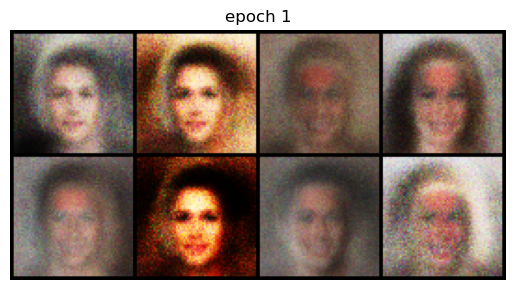

for epoch: 2/5... batch: 1..G-loss:1.9091198444366455... D-loss: 0.4555492401123047
for epoch: 2/5... batch: 51..G-loss:2.324439525604248... D-loss: 0.44772785902023315
for epoch: 2/5... batch: 101..G-loss:2.1783547401428223... D-loss: 0.4229329228401184
for epoch: 2/5... batch: 151..G-loss:2.21516752243042... D-loss: 0.3556676506996155
for epoch: 2/5... batch: 201..G-loss:2.4848852157592773... D-loss: 0.40504732728004456
for epoch: 2/5... batch: 251..G-loss:1.7855112552642822... D-loss: 0.4707218408584595
for epoch: 2/5... batch: 301..G-loss:1.9102084636688232... D-loss: 0.5161119699478149
for epoch: 2/5... batch: 351..G-loss:2.096217155456543... D-loss: 0.411838173866272
for epoch: 2/5... batch: 401..G-loss:1.9615620374679565... D-loss: 0.4038209915161133
for epoch: 2/5... batch: 451..G-loss:1.880316138267517... D-loss: 0.4842374324798584
for epoch: 2/5... batch: 501..G-loss:1.5206108093261719... D-loss: 0.47509729862213135
for epoch: 2/5... batch: 551..G-loss:2.731553554534912... D-

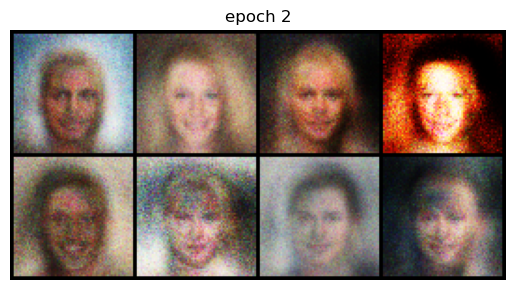

for epoch: 3/5... batch: 1..G-loss:1.5591753721237183... D-loss: 0.5124545097351074


In [ ]:
train(generator,discriminator,dataloader,epochs=5)